## **Loaded the data directly from drive**

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/Deep Learning Dataset "

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
data = []

for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)
    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            data.append({
                "filename": os.path.join(class_path, img),
                "class": class_name
            })

df = pd.DataFrame(data)
print(df.head())
print("Total images:", len(df))

                                            filename     class
0  /content/drive/MyDrive/Deep Learning Dataset /...  Building
1  /content/drive/MyDrive/Deep Learning Dataset /...  Building
2  /content/drive/MyDrive/Deep Learning Dataset /...  Building
3  /content/drive/MyDrive/Deep Learning Dataset /...  Building
4  /content/drive/MyDrive/Deep Learning Dataset /...  Building
Total images: 2381


## **show how many images in each class**

In [ ]:
import os
for cls in os.listdir(DATASET_PATH):
    print(cls, len(os.listdir(os.path.join(DATASET_PATH, cls))))
#there is an imbalance we'll deal with it using more weights for the lesser classes

Building 375
Car 534
Lab 448
Person 441
Tree 583


## **Preprocessing images and splitting data**

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["class"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50, #so this makes it 15% validation and 15% testing
    stratify=temp_df["class"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 1666
Validation: 357
Test: 358


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

#train data
IMG_SIZE = 300
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3]
)


train_data = train_gen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)


Found 1285 validated image filenames belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 381 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


In [ ]:
#validation data and testing (no agumentation, no shuffling especially testing cuz lables depend on this, keras assumean order of things)
val_test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


#validation
val_data = val_test_gen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)



#testing
test_data = val_test_gen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)



Found 282 validated image filenames belonging to 5 classes.
Found 283 validated image filenames belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 75 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 75 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


## **Imbalance penalitization**

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(1.1125541125541125), 1: np.float64(0.8006230529595015), 2: np.float64(1.7019867549668874), 3: np.float64(1.1473214285714286), 4: np.float64(0.7178770949720671)}


In [ ]:
'''from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)
'''

'from tensorflow.keras.applications import EfficientNetB0\nfrom tensorflow.keras.applications.efficientnet import preprocess_input\ntrain_gen = ImageDataGenerator(\n    preprocessing_function=preprocess_input,\n    validation_split=0.2,\n    rotation_range=15,\n    zoom_range=0.1,\n    horizontal_flip=True\n)\n\nval_gen = ImageDataGenerator(\n    preprocessing_function=preprocess_input,\n    validation_split=0.2\n)\n'

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Reshape, Multiply

def se_block(input_tensor, ratio=16):
    channels = input_tensor.shape[-1]

    se = GlobalAveragePooling2D()(input_tensor)
    se = Dense(channels // ratio, activation="relu")(se)
    se = Dense(channels, activation="sigmoid")(se)
    se = Reshape((1, 1, channels))(se)

    return Multiply()([input_tensor, se])


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output

x = se_block(x)

x = GlobalAveragePooling2D()(x)
x = Dropout(0.55)(x)
output = Dense(5, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy", Precision(name="precision"), Recall(name="recall")]
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        512 │ block1a_se_excit

 Total params: 4,262,136 (16.26 MB)

 Trainable params: 212,565 (830.33 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,      # reduce LR to 30%
    patience=1,      # wait 1 epoch before reducing
    min_lr=1e-6,
    verbose=1
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stopping, reduce_lr,checkpoint],
    class_weight=class_weights
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 1/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.4897 - loss: 1.3147 - precision: 0.7457 - recall: 0.1327 
Epoch 1: val_loss improved from inf to 0.51079, saving model to best_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 733s 17s/step - accuracy: 0.4948 - loss: 1.3058 - precision: 0.7510 - recall: 0.1387 - val_accuracy: 0.8440 - val_loss: 0.5108 - val_precision: 0.8934 - val_recall: 0.7730 - learning_rate: 0.0010
Epoch 2/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9035 - loss: 0.3774 - precision: 0.9441 - recall: 0.8479
Epoch 2: val_loss improved from 0.51079 to 0.36707, saving model to best_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 396s 10s/step - accuracy: 0.9038 - loss: 0.3758 - precision: 0.9442 - recall: 0.8486 - val_accuracy: 0.8865 - val_loss: 0.3671 - val_precision: 0.9067 - val_recall: 0.8617 - learning_rate: 0.0010
Epoch 3/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9389 - loss: 0.2244 - precision: 0.9560 - recall: 0.9148
Epoch 3: val_loss improved

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

val_preds = model.predict(val_data)
y_pred = np.argmax(val_preds, axis=1)
y_true = val_data.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=list(val_data.class_indices.keys())
))


9/9 ━━━━━━━━━━━━━━━━━━━━ 66s 6s/step
              precision    recall  f1-score   support

    Building       0.88      0.98      0.93        53
         Car       0.96      1.00      0.98        71
         Lab       1.00      1.00      1.00        31
      Person       0.96      0.96      0.96        47
        Tree       0.99      0.88      0.93        80

    accuracy                           0.95       282
   macro avg       0.96      0.96      0.96       282
weighted avg       0.96      0.95      0.95       282



In [ ]:
#model.save("multiclassification_5_classes_campus_model.keras")

## **Model Evaluation**

In [ ]:
test_loss, test_acc, test_precision, test_recall = model.evaluate(test_data)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


9/9 ━━━━━━━━━━━━━━━━━━━━ 103s 11s/step - accuracy: 0.9706 - loss: 0.1136 - precision: 0.9704 - recall: 0.9645
Test Accuracy: 0.9541
Test Precision: 0.9539
Test Recall: 0.9505


In [ ]:
import numpy as np

y_true = test_data.classes
y_pred_probs = model.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(test_data.class_indices.keys())


9/9 ━━━━━━━━━━━━━━━━━━━━ 65s 7s/step


<Figure size 800x800 with 0 Axes>

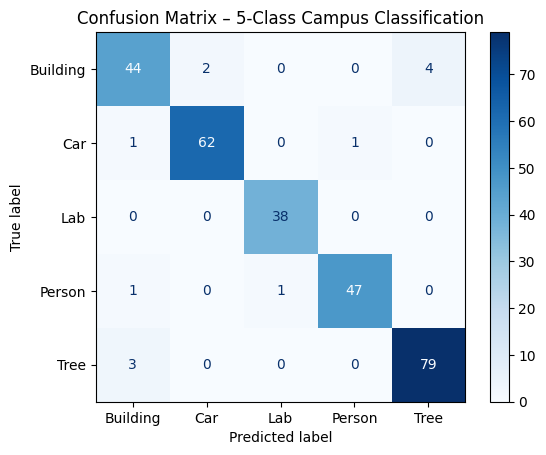

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(8, 8))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – 5-Class Campus Classification")
plt.show()


## **Fine Tuning the model (latest version we worked on doesnt need anything below but its good for documentation i think?)**

In [ ]:
#augmentation
'''train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    validation_split=0.2
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)
'''

'train_gen = ImageDataGenerator(\n    preprocessing_function=preprocess_input,\n    rotation_range=25,\n    zoom_range=0.25,\n    width_shift_range=0.15,\n    height_shift_range=0.15,\n    horizontal_flip=True,\n    brightness_range=[0.7, 1.3],\n    validation_split=0.2\n)\n\nval_gen = ImageDataGenerator(\n    preprocessing_function=preprocess_input,\n    validation_split=0.2\n)\n'

In [ ]:
'''train_data = train_gen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data = val_gen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)
'''

'train_data = train_gen.flow_from_directory(\n    DATASET_PATH,\n    target_size=(IMG_SIZE, IMG_SIZE),\n    batch_size=BATCH_SIZE,\n    class_mode="categorical",\n    subset="training",\n    shuffle=True\n)\n\nval_data = val_gen.flow_from_directory(\n    DATASET_PATH,\n    target_size=(IMG_SIZE, IMG_SIZE),\n    batch_size=BATCH_SIZE,\n    class_mode="categorical",\n    subset="validation",\n    shuffle=False\n)\n'

In [ ]:
'''base_model.trainable = True

# Freeze first 70% of layers
for layer in base_model.layers[:int(0.8 * len(base_model.layers))]:
    layer.trainable = False
'''

'base_model.trainable = True\n\n# Freeze first 70% of layers\nfor layer in base_model.layers[:int(0.8 * len(base_model.layers))]:\n    layer.trainable = False\n'

In [ ]:
#this is above but just to make sure im adding it here to give more weight to classes with less examples
'''class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
'''

'class_weights = compute_class_weight(\n    class_weight="balanced",\n    classes=np.unique(train_data.classes),\n    y=train_data.classes\n)\n\nclass_weights = dict(enumerate(class_weights))\n'

In [ ]:
'''import tensorflow as tf
loss_cate = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=loss_cate,
    metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)
'''

'import tensorflow as tf\nloss_cate = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)\nmodel.compile(\n    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),\n    loss=loss_cate,\n    metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]\n)\n'

In [ ]:
'''history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)
'''

'history_finetune = model.fit(\n    train_data,\n    validation_data=val_data,\n    epochs=10,\n    callbacks=[early_stopping, reduce_lr]\n)\n'

In [ ]:
#conitnue on the training without rerunning code aobve bc it looks promising but assigning a new learning rate
'''model.optimizer.learning_rate.assign(3e-6)

history_continue = model.fit(
    train_data,
    validation_data=val_data,
    epochs=16,
    initial_epoch=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)
'''

'model.optimizer.learning_rate.assign(3e-6)\n\nhistory_continue = model.fit(\n    train_data,\n    validation_data=val_data,\n    epochs=16,\n    initial_epoch=10,\n    class_weight=class_weights,\n    callbacks=[early_stopping, reduce_lr]\n)\n'

In [ ]:
'''import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

val_preds = model.predict(val_data)
y_pred = np.argmax(val_preds, axis=1)
y_true = val_data.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=list(val_data.class_indices.keys())
))
'''

'import numpy as np\nfrom sklearn.metrics import confusion_matrix, classification_report\n\nval_preds = model.predict(val_data)\ny_pred = np.argmax(val_preds, axis=1)\ny_true = val_data.classes\n\nprint(classification_report(\n    y_true,\n    y_pred,\n    target_names=list(val_data.class_indices.keys())\n))\n'